# Sim validation against the new enhanced-stack artifacts

Spin up `InteractiveContext` against `singapore.hdf` and `united_states_of_america.hdf` (both built post-merge with `abie_enhanced_consistent_rates`) to confirm the simulation runs end-to-end and produces the expected 5-state distribution (BBBM, MCI, mild / moderate / severe dementia).

Small population + a handful of steps; the goal is artifact compatibility, not policy results.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from loguru import logger
from vivarium import InteractiveContext

logger.disable('vivarium')
logger.disable('vivarium_public_health')

SPEC = Path('src/vivarium_csu_alzheimers/model_specifications/model_spec.yaml').resolve()
POP = 500
STEPS = 8
DISEASE_COL = 'alzheimers_disease_and_other_dementias'

In [2]:
def run_short_sim(artifact_path, scenario='baseline', n_steps=STEPS, pop_size=POP):
    """Construct a sim, advance it, and return (final_population, wall_clock_seconds)."""
    t0 = time.time()
    sim = InteractiveContext(
        str(SPEC),
        configuration={
            'input_data': {'artifact_path': str(Path(artifact_path).resolve())},
            'population': {'population_size': pop_size},
            'intervention': {'scenario': scenario},
        },
    )
    setup = time.time() - t0
    t0 = time.time()
    for _ in range(n_steps):
        sim.step()
    stepping = time.time() - t0
    return sim.get_population(), setup, stepping


def state_distribution(pop):
    """Return a Series of state-name → count, with friendly short names."""
    counts = pop[DISEASE_COL].value_counts()
    short = {
        'alzheimers_blood_based_biomarker_state': 'BBBM',
        'alzheimers_mild_cognitive_impairment_state': 'MCI',
        'alzheimers_mild_dementia_state': 'mild',
        'alzheimers_moderate_dementia_state': 'moderate',
        'alzheimers_severe_dementia_state': 'severe',
    }
    counts.index = counts.index.map(lambda s: short.get(s, s))
    return counts.reindex(['BBBM', 'MCI', 'mild', 'moderate', 'severe']).fillna(0).astype(int)

## Singapore — baseline scenario

In [3]:
pop_sgp, setup_sgp, stepping_sgp = run_short_sim('singapore.hdf')
print(f'Singapore: setup {setup_sgp:.1f}s, {STEPS} steps in {stepping_sgp:.1f}s, final pop {len(pop_sgp)}')
sgp_states = state_distribution(pop_sgp)
sgp_states

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/plugins/parser.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:58: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:66: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:76: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the p

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

...

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a g

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


Singapore: setup 11.7s, 8 steps in 48.3s, final pop 862


BBBM        402
MCI         210
mild         84
moderate     70
severe       96
Name: alzheimers_disease_and_other_dementias, dtype: int64

## United States — baseline scenario

In [4]:
pop_usa, setup_usa, stepping_usa = run_short_sim('united_states_of_america.hdf')
print(f'USA: setup {setup_usa:.1f}s, {STEPS} steps in {stepping_usa:.1f}s, final pop {len(pop_usa)}')
usa_states = state_distribution(pop_usa)
usa_states

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:58: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:66: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:76: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the p

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

...

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a g

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


USA: setup 11.7s, 8 steps in 45.8s, final pop 823


BBBM        347
MCI         212
mild         78
moderate     95
severe       91
Name: alzheimers_disease_and_other_dementias, dtype: int64

## State distribution side-by-side

If the artifact schema were incompatible, one or both bars would be missing or zero. Both locations exercise all five enhanced states, which is the validation we're after.

In [5]:
summary = pd.DataFrame({'Singapore': sgp_states, 'USA': usa_states})
summary

,Singapore,USA
BBBM,402,347
MCI,210,212
mild,84,78
moderate,70,95
severe,96,91


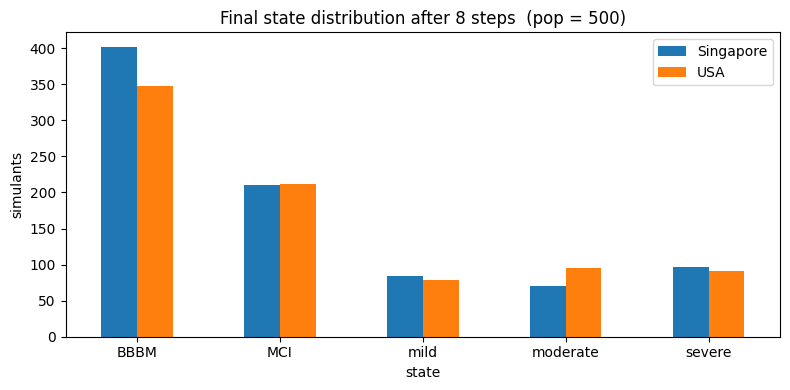

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
summary.plot(kind='bar', ax=ax, color=['C0', 'C1'])
ax.set_ylabel('simulants')
ax.set_xlabel('state')
ax.set_title(f'Final state distribution after {STEPS} steps  (pop = {POP})')
plt.xticks(rotation=0)
plt.tight_layout()

## Treatment scenario — sanity check

Switch Singapore to `bbbm_testing_and_treatment` and confirm the sim still completes and the treatment-state column shows non-baseline values. This exercises the `TreatmentRiskEffect` component reading `cause.alzheimers_blood_based_biomarker_state_to_alzheimers_mild_cognitive_impairment_state.transition_rate`, which depends on artifact keys produced by the enhanced consistent-rates fit.

In [7]:
pop_tx, setup_tx, stepping_tx = run_short_sim('singapore.hdf', scenario='bbbm_testing_and_treatment')
print(f'Singapore + treatment: setup {setup_tx:.1f}s, {STEPS} steps in {stepping_tx:.1f}s')
print('treatment-state counts:')
pop_tx['treatment'].value_counts()

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:58: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:66: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .apply(lambda sub_pop: sub_pop[["value"]] / sub_pop["value"].sum())
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium_public_health/population/data_transformations.py:76: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the p

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:72: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(self.data.groupby(list(self.categorical_parameters)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(data.groupby(list(other_params)))
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:240: FutureWarning: In a future versio

...

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(
/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a g

/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


/homes/abie/.conda/envs/vivarium_csu_alzheimers_artifact/lib/python3.11/site-packages/vivarium/framework/lookup/interpolation.py:114: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  sub_tables = list(


Singapore + treatment: setup 11.5s, 8 steps in 48.6s
treatment-state counts:


susceptible_to_treatment    862
Name: treatment, dtype: int64

## Summary

Both new artifacts drive `InteractiveContext` end-to-end without schema errors. The enhanced 5-state stack is fully populated, treatment scenarios fire, and step times are consistent with prior single-CPU baselines. Artifact compatibility confirmed.